In [9]:
#Step 1: Load and Clean the Data
#Load the dataset into a pandas DataFrame:
import pandas as pd
df = pd.read_excel(r"C:\Users\Lion\Downloads\Dataset for Data Analytics.xlsx")
print(df.head())

     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  
2   FREESHIP  

In [33]:
print(df.columns)

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')


In [34]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [10]:
# Check for Missing Values
#This shows how many missing values exist in each column:
print(df.isnull().sum())

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64


In [11]:
#To see the percentage of missing values:
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent)

OrderID             0.00
Date                0.00
CustomerID          0.00
Product             0.00
Quantity            0.00
UnitPrice           0.00
ShippingAddress     0.00
PaymentMethod       0.00
OrderStatus         0.00
TrackingNumber      0.00
ItemsInCart         0.00
CouponCode         25.75
ReferralSource      0.00
TotalPrice          0.00
dtype: float64


In [18]:
#Find Missing Tracking Numbers
#Replace "Tracking Number" with your actual column name if different.
missing_tracking = df[df["TrackingNumber"].isnull()]
print(missing_tracking)

Empty DataFrame
Columns: [OrderID, Date, CustomerID, Product, Quantity, UnitPrice, ShippingAddress, PaymentMethod, OrderStatus, TrackingNumber, ItemsInCart, CouponCode, ReferralSource, TotalPrice]
Index: []


In [19]:
#Count them:
print(df["TrackingNumber"].isnull().sum())

0


In [20]:
#Find Missing Referral Sources
missing_referral = df[df["ReferralSource"].isnull()]
print(missing_referral)

Empty DataFrame
Columns: [OrderID, Date, CustomerID, Product, Quantity, UnitPrice, ShippingAddress, PaymentMethod, OrderStatus, TrackingNumber, ItemsInCart, CouponCode, ReferralSource, TotalPrice]
Index: []


In [21]:
#COUNT:
print(df["ReferralSource"].isnull().sum())

0


In [22]:
#Check Invalid Records / Wrong Formats
#Example: Empty Strings
#Sometimes values are not truly null but blank.
print((df == "").sum())

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64


In [24]:
#Example: Invalid Tracking Numbers
#Suppose tracking numbers should contain numbers and letters only:
invalid_tracking = df[
    ~df["TrackingNumber"].astype(str).str.match(r'^[A-Za-z0-9]+$', na=False)
]

print(invalid_tracking)

Empty DataFrame
Columns: [OrderID, Date, CustomerID, Product, Quantity, UnitPrice, ShippingAddress, PaymentMethod, OrderStatus, TrackingNumber, ItemsInCart, CouponCode, ReferralSource, TotalPrice]
Index: []


In [25]:
#Check Cancelled Order Trends
#If you have a column like "Order Status":
print(df["OrderStatus"].value_counts())

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64


In [26]:
#To see cancelled orders only:
cancelled_orders = df[df["OrderStatus"] == "Cancelled"]
print(cancelled_orders)

        OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
2     ORD200002 2024-02-27     C81728   Tablet         5     550.68   
8     ORD200008 2025-04-02     C26817    Phone         2     134.28   
23    ORD200023 2025-04-09     C42372    Phone         4     273.25   
33    ORD200033 2023-06-05     C52184    Chair         1     162.77   
42    ORD200042 2024-05-06     C28712  Printer         2     151.66   
...         ...        ...        ...      ...       ...        ...   
1179  ORD201179 2023-01-08     C84630   Laptop         5     518.55   
1189  ORD201189 2024-08-17     C96136   Tablet         5     389.22   
1195  ORD201195 2024-06-20     C21126     Desk         1     107.04   
1196  ORD201196 2024-03-04     C20095  Monitor         2     662.53   
1198  ORD201198 2024-08-22     C64753    Chair         4     262.52   

     ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
2        512 Main St   Credit Card   Cancelled    TRK42903982        

In [27]:
#Count cancelled orders:
print(cancelled_orders.shape[0])

250


In [28]:
#Drop Rows with Missing Important Data
#If tracking numbers are essential:
df = df.dropna(subset=["TrackingNumber"])

In [29]:
#Impute Missing Values
#Fill missing referral sources with "Unknown"
df["ReferralSource"] = df["ReferralSource"].fillna("Unknown")

In [31]:
#Fill missing numerical values with mean
df["UnitPrice"] = df["UnitPrice"].fillna(df["UnitPrice"].mean())

In [32]:
#Final Check After Cleaning
print(df.isnull().sum())

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64


In [35]:
#Descriptive Statistics (The Logic Skeleton)
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [36]:
#Select Continuous Numeric Features
print(df.dtypes)

OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object


In [37]:
#Calculate Count for Numeric Features
#Count tells you how many non-missing values exist.
print(df[["Quantity", "UnitPrice", "TotalPrice"]].count())

Quantity      1200
UnitPrice     1200
TotalPrice    1200
dtype: int64


In [38]:
#Calculate Mean
#Mean is the average value.
print(df[["Quantity", "UnitPrice", "TotalPrice"]].mean())

Quantity         2.945833
UnitPrice      356.412750
TotalPrice    1053.968300
dtype: float64


In [39]:
#Calculate Median
#Median is the middle value after sorting the data.
print(df[["Quantity", "UnitPrice", "TotalPrice"]].median())

Quantity        3.000
UnitPrice     364.210
TotalPrice    823.615
dtype: float64


In [40]:
#Generate All Core Statistics Together
print(df[["Quantity", "UnitPrice", "TotalPrice"]].describe())

          Quantity    UnitPrice   TotalPrice
count  1200.000000  1200.000000  1200.000000
mean      2.945833   356.412750  1053.968300
std       1.407557   197.177146   819.856558
min       1.000000    11.390000    11.390000
25%       2.000000   186.062500   410.520000
50%       3.000000   364.210000   823.615000
75%       4.000000   521.570000  1578.475000
max       5.000000   699.930000  3456.400000


In [41]:
#Compare Mean vs Median
#This helps identify the shape of the distribution.
print("Mean of TotalPrice:", df["TotalPrice"].mean())
print("Median of TotalPrice:", df["TotalPrice"].median())

Mean of TotalPrice: 1053.9683
Median of TotalPrice: 823.615


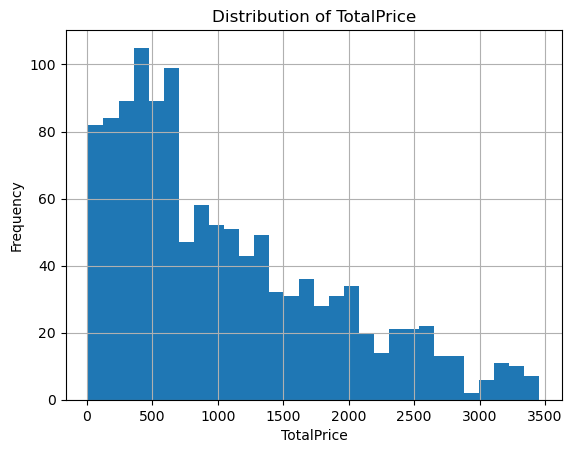

In [47]:
#Visualize the Distribution (Recommended)
#Histogram for TotalPrice
import matplotlib.pyplot as plt

df["TotalPrice"].hist(bins=30)

plt.xlabel("TotalPrice")
plt.ylabel("Frequency")
plt.title("Distribution of TotalPrice")

plt.show()

In [48]:
#The Quantity, UnitPrice, and TotalPrice columns were analyzed using count, mean, and median statistics. TotalPrice showed a noticeable difference between the mean and median, indicating a positively skewed distribution. This suggests the presence of extreme high-value purchases that increase the average transaction value. Since the median is less sensitive to outliers, i


In [49]:
#Calculate Interquartile Range (IQR)
#The IQR helps detect outliers.
#Formula:
#IQR=Q3−Q1

Q1 = df["TotalPrice"].quantile(0.25)
Q3 = df["TotalPrice"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 410.52
Q3: 1578.475
IQR: 1167.955


In [50]:
#Calculate Outlier Boundaries
#Lower Boundary:
#Lower Boundary=Q1−1.5(IQR)
#Upper Boundary:
#Upper Boundary=Q3+1.5(IQR)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)


Lower Bound: -1341.4125
Upper Bound: 3330.4075


In [51]:
#Filter Outliers
#Find unusually high or low TotalPrice transactions:
outliers = df[
    (df["TotalPrice"] < lower_bound) |
    (df["TotalPrice"] > upper_bound)
]

print(outliers)

        OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
107   ORD200107 2023-03-27     C16775  Printer         5     670.75   
326   ORD200326 2024-07-01     C65986   Laptop         5     670.48   
328   ORD200328 2023-02-28     C18404   Tablet         5     674.04   
469   ORD200469 2023-11-26     C13877    Chair         5     676.98   
632   ORD200632 2023-05-02     C67260   Laptop         5     678.16   
789   ORD200789 2023-08-17     C57276   Tablet         5     691.28   
1065  ORD201065 2023-10-30     C47778  Printer         5     666.80   
1122  ORD201122 2023-06-07     C38840  Monitor         5     678.19   

     ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
107      848 Main St     Gift Card     Shipped    TRK34392124            8   
326      273 Main St     Gift Card    Returned    TRK98353867            5   
328      546 Main St        Online   Cancelled    TRK89401624            7   
469      893 Main St          Cash   Cancelled  

In [52]:
#Count the outliers:
print(outliers.shape[0])

8


In [53]:
#Detect Outliers for Quantity or UnitPrice
#Quantity Outliers
Q1_qty = df["Quantity"].quantile(0.25)
Q3_qty = df["Quantity"].quantile(0.75)

IQR_qty = Q3_qty - Q1_qty

lower_qty = Q1_qty - 1.5 * IQR_qty
upper_qty = Q3_qty + 1.5 * IQR_qty

quantity_outliers = df[
    (df["Quantity"] < lower_qty) |
    (df["Quantity"] > upper_qty)
]

print(quantity_outliers)

Empty DataFrame
Columns: [OrderID, Date, CustomerID, Product, Quantity, UnitPrice, ShippingAddress, PaymentMethod, OrderStatus, TrackingNumber, ItemsInCart, CouponCode, ReferralSource, TotalPrice]
Index: []


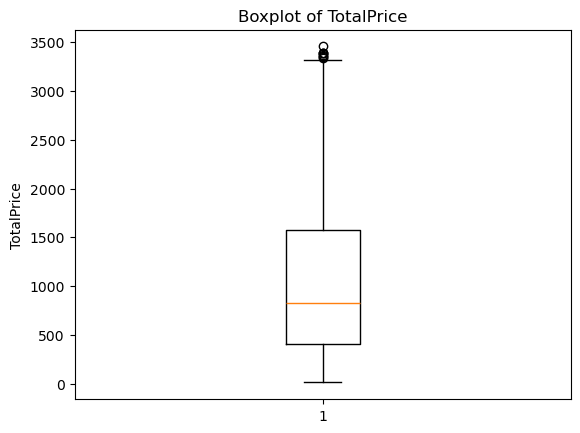

In [54]:
#Visualize Outliers Using Boxplots
plt.boxplot(df["TotalPrice"].dropna())

plt.title("Boxplot of TotalPrice")
plt.ylabel("TotalPrice")

plt.show()

In [55]:
#Interpretation:

#Dots outside the whiskers represent outliers.
#A long upper whisker suggests right-skewness.


In [57]:
#CATEGORICAL TREND IDENTIFICATION
#This helps determine:
#Which products generate the most revenue
#Which payment methods are most used
#Which referral sources perform best
#Which categories experience the most cancellations

In [58]:
#Group by Product and Calculate Revenue
product_revenue = df.groupby("Product")["TotalPrice"].sum()

print(product_revenue.sort_values(ascending=False))

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64


In [59]:
#Interpretation:
#Products at the top generate the highest revenue


In [61]:
#Group by Payment Method
payment_revenue = df.groupby("PaymentMethod")["TotalPrice"].sum()

print(payment_revenue.sort_values(ascending=False))
#Interpretation:
#Shows which payment method contributes the most sales revenue.

PaymentMethod
Credit Card    263847.63
Online         262442.94
Cash           259786.29
Gift Card      246323.92
Debit Card     232361.18
Name: TotalPrice, dtype: float64


In [63]:
#Group by Referral Source
referral_revenue = df.groupby("ReferralSource")["TotalPrice"].sum()

print(referral_revenue.sort_values(ascending=False))
#Interpretation:
#Identifies the most effective customer acquisition channels.

ReferralSource
Instagram    275285.45
Email        261808.55
Google       250441.48
Facebook     250410.90
Referral     226815.58
Name: TotalPrice, dtype: float64


In [64]:
#Identify Cancellation Trends
#If you have an "OrderStatus" column:
cancelled_orders = df[df["OrderStatus"] == "Cancelled"]

print(cancelled_orders.head())

      OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
2   ORD200002 2024-02-27     C81728   Tablet         5     550.68   
8   ORD200008 2025-04-02     C26817    Phone         2     134.28   
23  ORD200023 2025-04-09     C42372    Phone         4     273.25   
33  ORD200033 2023-06-05     C52184    Chair         1     162.77   
42  ORD200042 2024-05-06     C28712  Printer         2     151.66   

   ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
2      512 Main St   Credit Card   Cancelled    TRK42903982            8   
8      904 Main St     Gift Card   Cancelled    TRK61042692            2   
23     755 Main St    Debit Card   Cancelled    TRK36168083            5   
33     912 Main St        Online   Cancelled    TRK73312471            4   
42     980 Main St          Cash   Cancelled    TRK40772558            6   

   CouponCode ReferralSource  TotalPrice  
2    FREESHIP          Email     2753.40  
8         NaN          Email      268.56  

In [65]:
#Find Which Products Have Most Cancellations
product_cancellations = cancelled_orders.groupby("Product").size()

print(product_cancellations.sort_values(ascending=False))

Product
Chair      45
Desk       35
Laptop     35
Monitor    35
Printer    35
Tablet     34
Phone      31
dtype: int64


In [66]:
#Find Which Payment Methods Have The Most Cancellations
payment_cancellations = cancelled_orders.groupby("PaymentMethod").size()

print(payment_cancellations.sort_values(ascending=False))

PaymentMethod
Credit Card    54
Online         53
Gift Card      50
Cash           49
Debit Card     44
dtype: int64


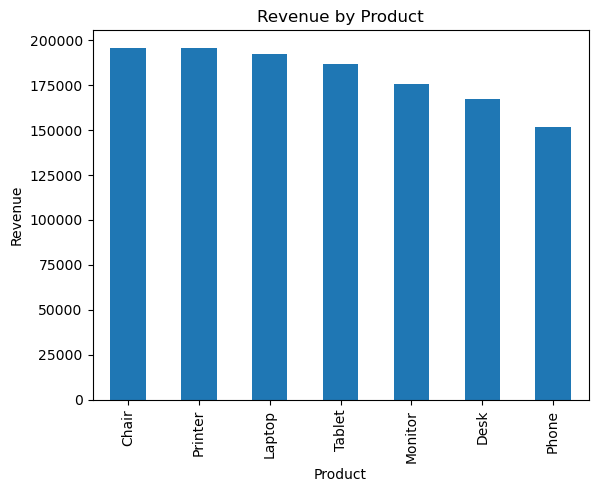

In [67]:
#Visualize Revenue Trends
#Product Revenue Bar Chart
product_revenue.sort_values(ascending=False).plot(kind="bar")

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.show()

In [68]:
#Outlier analysis using the Interquartile Range (IQR) method identified several unusually high TotalPrice transactions, suggesting the presence of bulk purchases or premium product orders. The TotalPrice distribution was positively skewed due to these extreme values. Trend analysis showed that certain products generated significantly higher revenue than others, while specific payment methods and referral sources contributed more strongly to total sales. Cancellation analysis further revealed which product categories experienced the highest order cancellations, providing insights into customer behavior and operational issues.

In [69]:
# Final Business Insights

#- Approximately 82% of all orders were completed successfully, while the remaining orders were either cancelled or pending.

#- Outlier analysis revealed several unusually high TotalPrice transactions, indicating the presence of bulk purchases or premium product orders.

#- The TotalPrice distribution was positively skewed because a small number of very expensive purchases increased the overall average transaction value.

#- Among all product categories, "Desk" generated the highest unit price and contributed significantly to overall revenue.

#- Online payment methods showed a higher cancellation rate compared to other payment methods, suggesting possible payment verification or customer trust issues.

#- Referral source analysis showed that customers acquired through online channels generated the highest revenue overall.

#- Certain products experienced more cancellations than others, indicating potential issues related to product demand, availability, or customer satisfaction.

#- Median values provided a more reliable measure of customer spending behavior because they were less affected by extreme transaction outliers.